# import Libraries

In [967]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore
%matplotlib inline

#  Read Data

In [968]:
## read data
weather= pd.read_csv("data/weather_burbank_airport.csv")
charging=pd.read_csv("data/charging_sessions.csv")
weather.head(10)

,city,timestamp,temperature,cloud_cover,cloud_cover_description,pressure,windspeed,precipitation,felt_temperature
0,Burbank,2018-01-01 08:53:00,9.0,33.0,Fair,991.75,9.0,0.0,8.0
1,Burbank,2018-01-01 09:53:00,9.0,33.0,Fair,992.08,0.0,0.0,9.0
2,Burbank,2018-01-01 10:53:00,9.0,21.0,Haze,992.08,0.0,0.0,9.0
3,Burbank,2018-01-01 11:53:00,9.0,29.0,Partly Cloudy,992.08,0.0,0.0,9.0
4,Burbank,2018-01-01 12:53:00,8.0,33.0,Fair,992.08,0.0,0.0,8.0
5,Burbank,2018-01-01 13:53:00,8.0,33.0,Fair,992.08,0.0,0.0,8.0
6,Burbank,2018-01-01 14:53:00,7.0,30.0,Partly Cloudy,992.08,0.0,0.0,7.0
7,Burbank,2018-01-01 15:53:00,8.0,34.0,Fair,992.41,0.0,0.0,8.0
8,Burbank,2018-01-01 16:53:00,12.0,34.0,Fair,993.39,0.0,0.0,12.0
9,Burbank,2018-01-01 17:53:00,16.0,34.0,Fair,994.05,0.0,0.0,16.0


## check the weather dataset

In [969]:
weather.info()
### The columns of temperature,cloud_cover,cloud_cover_description,pressure, windspeed and felt_temperature have missing values.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29244 entries, 0 to 29243
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   city                     29244 non-null  object 
 1   timestamp                29244 non-null  object 
 2   temperature              29219 non-null  float64
 3   cloud_cover              29224 non-null  float64
 4   cloud_cover_description  29224 non-null  object 
 5   pressure                 29236 non-null  float64
 6   windspeed                29158 non-null  float64
 7   precipitation            29244 non-null  float64
 8   felt_temperature         29218 non-null  float64
dtypes: float64(6), object(3)
memory usage: 2.0+ MB


### fill in the missing values

In [970]:
def missing(df):
    missing_number = df.isnull().sum().sort_values(ascending=False)
    missing_percent = (df.isnull().sum() / df.isnull().count()).sort_values(ascending=False)
    missing_values = pd.concat([missing_number, missing_percent], axis=1,keys=['missing_number','missing_percent'])
    total_missing_number=missing_number.sum()
    total_missing_percent=missing_percent.sum()
    total_row=pd.DataFrame([[total_missing_number,total_missing_percent]],
                           columns=['missing_number','missing_percent'],
                           index=['total'])
    missing_values=pd.concat([missing_values,total_row])
    return missing_values
### Define a function to show the number and percentage of missing values for each column, as well as the total number of missing values in the entire dataset.

In [971]:
missing(weather)
### filter out columns like ‘City,’ ‘Precipitation,’ and ‘Timestamp’ (no null values)

,missing_number,missing_percent
windspeed,86,0.002941
felt_temperature,26,0.000889
temperature,25,0.000855
cloud_cover,20,0.000684
cloud_cover_description,20,0.000684
pressure,8,0.000274
city,0,0.000000
timestamp,0,0.000000
precipitation,0,0.000000
total,185,0.006326


In [972]:
weather_filling=weather.drop(['timestamp','city','precipitation','cloud_cover_description'], axis=1)
print(weather_filling)
### Delete columns with no missing values and non-numeric columns.

       temperature  cloud_cover  pressure  windspeed  felt_temperature
0              9.0         33.0    991.75        9.0               8.0
1              9.0         33.0    992.08        0.0               9.0
2              9.0         21.0    992.08        0.0               9.0
3              9.0         29.0    992.08        0.0               9.0
4              8.0         33.0    992.08        0.0               8.0
...            ...          ...       ...        ...               ...
29239         13.0         33.0    986.81        0.0              13.0
29240         12.0         33.0    986.81       11.0              12.0
29241         12.0         33.0    987.47        9.0              12.0
29242         11.0         33.0    987.14       13.0              11.0
29243         10.0         33.0    987.80        6.0              10.0

[29244 rows x 5 columns]


In [973]:
### Fill missing values with the mean values from the three rows above and below in the same column
for col in weather_filling.columns:
        if weather_filling[col].isnull().any():
            rolling_mean=weather_filling[col].rolling(window=7,min_periods=1,center=True).mean()
            weather_filling[col]=weather_filling[col].fillna(rolling_mean)
missing(weather_filling)

,missing_number,missing_percent
temperature,0,0.0
cloud_cover,0,0.0
pressure,0,0.0
windspeed,0,0.0
felt_temperature,0,0.0
total,0,0.0


In [974]:
### update original weather data
weather.update(weather_filling)
missing(weather)

,missing_number,missing_percent
cloud_cover_description,20,0.000684
city,0,0.000000
timestamp,0,0.000000
temperature,0,0.000000
cloud_cover,0,0.000000
pressure,0,0.000000
windspeed,0,0.000000
precipitation,0,0.000000
felt_temperature,0,0.000000
total,20,0.000684


In [975]:
### fill non-numeric columns(cloud_cover_description)
weather['cloud_cover_description'] = weather['cloud_cover_description'].fillna(method='ffill')
missing(weather)

C:\Users\zp\AppData\Local\Temp\ipykernel_21032\1945171366.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  weather['cloud_cover_description'] = weather['cloud_cover_description'].fillna(method='ffill')


,missing_number,missing_percent
city,0,0.0
timestamp,0,0.0
temperature,0,0.0
cloud_cover,0,0.0
cloud_cover_description,0,0.0
pressure,0,0.0
windspeed,0,0.0
precipitation,0,0.0
felt_temperature,0,0.0
total,0,0.0


### Check for duplicates

In [976]:
weather.drop_duplicates
#### No duplicate data

<bound method DataFrame.drop_duplicates of           city            timestamp  temperature  cloud_cover  \
0      Burbank  2018-01-01 08:53:00          9.0         33.0   
1      Burbank  2018-01-01 09:53:00          9.0         33.0   
2      Burbank  2018-01-01 10:53:00          9.0         21.0   
3      Burbank  2018-01-01 11:53:00          9.0         29.0   
4      Burbank  2018-01-01 12:53:00          8.0         33.0   
...        ...                  ...          ...          ...   
29239  Burbank  2021-01-01 03:53:00         13.0         33.0   
29240  Burbank  2021-01-01 04:53:00         12.0         33.0   
29241  Burbank  2021-01-01 05:53:00         12.0         33.0   
29242  Burbank  2021-01-01 06:53:00         11.0         33.0   
29243  Burbank  2021-01-01 07:53:00         10.0         33.0   

      cloud_cover_description  pressure  windspeed  precipitation  \
0                        Fair    991.75        9.0            0.0   
1                        Fair    992.0

### Check for outlier

In [977]:
weather.describe()

,temperature,cloud_cover,pressure,windspeed,precipitation,felt_temperature
count,29244.000000,29244.000000,29244.000000,29244.000000,29244.000000,29244.000000
mean,17.883031,30.109382,986.879276,8.571036,0.059360,17.728579
std,6.453591,5.399077,3.606671,6.694556,0.471682,6.320396
min,2.000000,4.000000,971.000000,0.000000,0.000000,0.000000
25%,13.000000,26.000000,984.500000,6.000000,0.000000,13.000000
50%,17.000000,33.000000,986.480000,7.000000,0.000000,17.000000
75%,22.000000,34.000000,989.110000,13.000000,0.000000,22.000000
max,46.000000,47.000000,999.650000,57.000000,18.540000,42.000000


In [978]:
#### Generate a boxplot for the specified column, extract the outliers
#### and calculate the unique values of the outliers along with their frequencies.
def plot_outliers(column):
    plt.figure()
    boxplot=weather[column].plot(kind='box',return_type='dict')
    x=boxplot['fliers'][0].get_xdata()
    y=boxplot['fliers'][0].get_ydata()
    unique_values, counts = np.unique(y, return_counts=True)
    for value, count in zip(unique_values, counts):
        print(f"Value: {value}, Count: {count}")
    plt.title(f"Boxplot of {column}")
    plt.show()

    

Value: 36.0, Count: 100
Value: 37.0, Count: 56
Value: 38.0, Count: 20
Value: 39.0, Count: 10
Value: 40.0, Count: 2
Value: 41.0, Count: 10
Value: 42.0, Count: 7
Value: 43.0, Count: 2
Value: 44.0, Count: 8
Value: 45.0, Count: 8
Value: 46.0, Count: 2


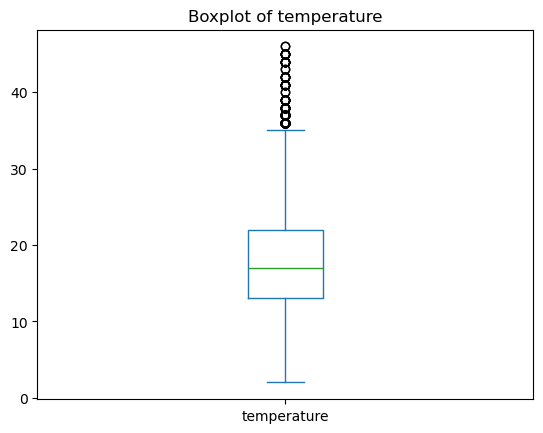

In [979]:
plot_outliers('temperature')

Value: 4.0, Count: 23
Value: 11.0, Count: 906
Value: 12.0, Count: 249
Value: 47.0, Count: 4


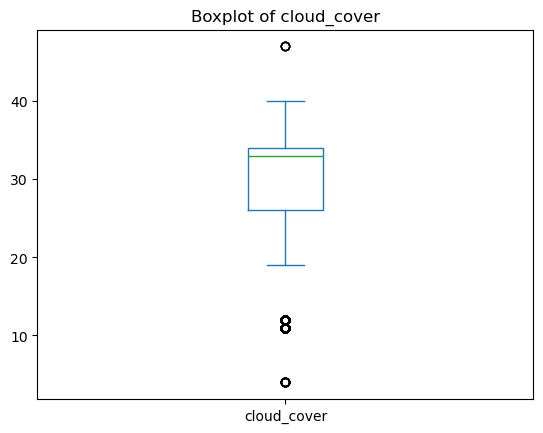

In [980]:
plot_outliers('cloud_cover')

Value: 971.0, Count: 2
Value: 971.33, Count: 2
Value: 971.66, Count: 4
Value: 971.99, Count: 2
Value: 972.32, Count: 3
Value: 972.65, Count: 3
Value: 972.98, Count: 1
Value: 973.31, Count: 13
Value: 973.64, Count: 11
Value: 973.97, Count: 11
Value: 974.3, Count: 10
Value: 974.63, Count: 12
Value: 974.95, Count: 10
Value: 975.28, Count: 12
Value: 975.61, Count: 19
Value: 975.94, Count: 9
Value: 976.27, Count: 14
Value: 976.6, Count: 11
Value: 976.93, Count: 18
Value: 977.26, Count: 7
Value: 996.03, Count: 60
Value: 996.36, Count: 56
Value: 996.69, Count: 47
Value: 997.02, Count: 34
Value: 997.34, Count: 17
Value: 997.67, Count: 21
Value: 998.0, Count: 18
Value: 998.33, Count: 15
Value: 998.66, Count: 10
Value: 998.99, Count: 5
Value: 999.32, Count: 2
Value: 999.65, Count: 5


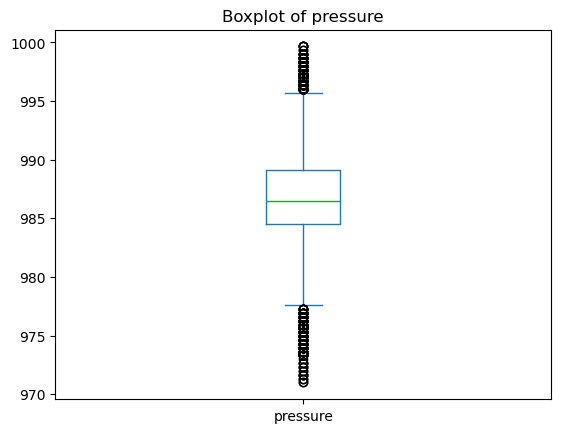

In [981]:
plot_outliers('pressure')

Value: 24.0, Count: 158
Value: 25.833333333333332, Count: 1
Value: 26.0, Count: 113
Value: 28.0, Count: 89
Value: 30.0, Count: 58
Value: 31.0, Count: 38
Value: 33.0, Count: 35
Value: 35.0, Count: 27
Value: 37.0, Count: 18
Value: 39.0, Count: 10
Value: 41.0, Count: 6
Value: 43.0, Count: 9
Value: 44.0, Count: 5
Value: 46.0, Count: 8
Value: 48.0, Count: 4
Value: 52.0, Count: 1
Value: 54.0, Count: 2
Value: 57.0, Count: 1


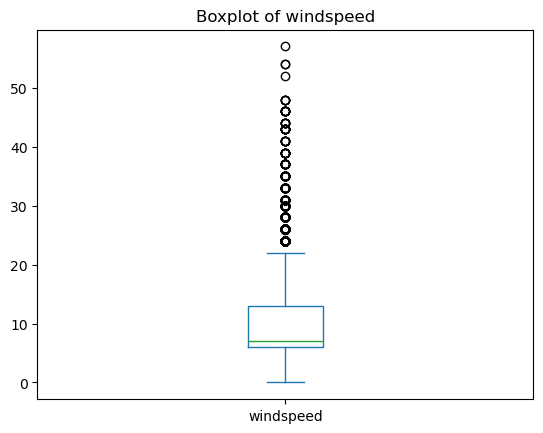

In [982]:
plot_outliers('windspeed')

Value: 0.25, Count: 313
Value: 0.51, Count: 158
Value: 0.76, Count: 125
Value: 1.02, Count: 86
Value: 1.27, Count: 80
Value: 1.52, Count: 59
Value: 1.78, Count: 50
Value: 2.03, Count: 31
Value: 2.29, Count: 32
Value: 2.54, Count: 33
Value: 2.79, Count: 23
Value: 3.05, Count: 11
Value: 3.3, Count: 20
Value: 3.56, Count: 12
Value: 3.81, Count: 7
Value: 4.06, Count: 6
Value: 4.32, Count: 15
Value: 4.57, Count: 9
Value: 4.83, Count: 9
Value: 5.08, Count: 13
Value: 5.33, Count: 8
Value: 5.59, Count: 4
Value: 5.84, Count: 4
Value: 6.1, Count: 4
Value: 6.35, Count: 2
Value: 6.6, Count: 2
Value: 6.86, Count: 6
Value: 7.11, Count: 1
Value: 7.37, Count: 3
Value: 7.62, Count: 3
Value: 7.87, Count: 2
Value: 8.13, Count: 2
Value: 8.38, Count: 1
Value: 8.64, Count: 2
Value: 9.91, Count: 3
Value: 10.67, Count: 1
Value: 10.92, Count: 1
Value: 11.18, Count: 1
Value: 11.43, Count: 1
Value: 12.45, Count: 1
Value: 12.7, Count: 1
Value: 13.97, Count: 1
Value: 18.54, Count: 1


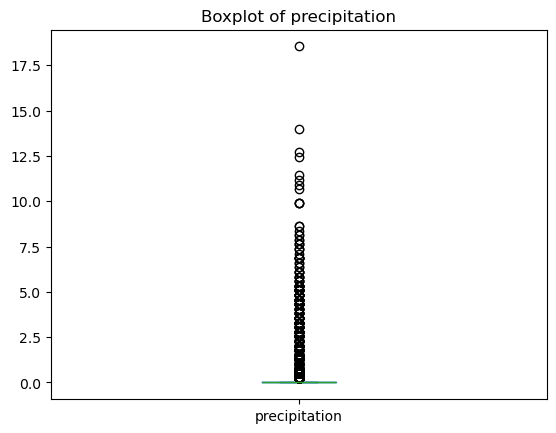

In [983]:
plot_outliers('precipitation')

Value: 36.0, Count: 38
Value: 37.0, Count: 21
Value: 38.0, Count: 13
Value: 39.0, Count: 11
Value: 40.0, Count: 6
Value: 41.0, Count: 13
Value: 42.0, Count: 6


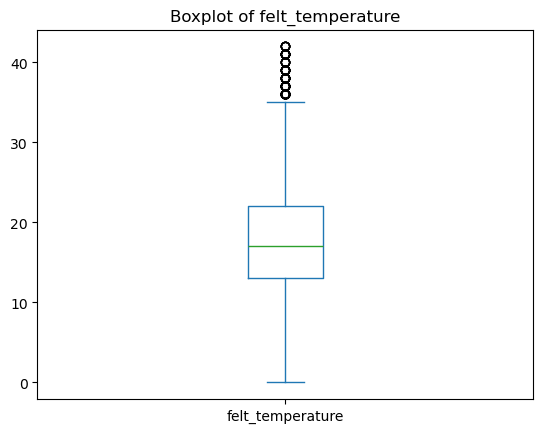

In [984]:
plot_outliers('felt_temperature')

##### I’m not sure how I should handle the outliers. We can discuss this during the group meeting

### Remove unnecessary columns from the DataFrame

In [985]:
weather['city'].unique()
# Since there is only one city, Burbank, which is located in Los Angeles, it is not meaningful for further modeling, so we will drop this column.

array(['Burbank'], dtype=object)

In [986]:
weather = weather.drop(columns=['city'])

In [987]:
# check the data type of each column
weather.dtypes

timestamp                   object
temperature                float64
cloud_cover                float64
cloud_cover_description     object
pressure                   float64
windspeed                  float64
precipitation              float64
felt_temperature           float64
dtype: object

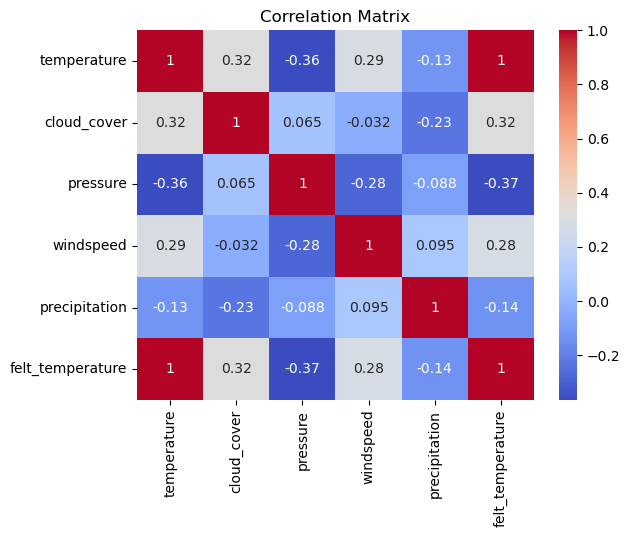

In [988]:
#check for correlation
numeric_columns = weather.select_dtypes(include=['float64'])
correlation_matrix = numeric_columns .corr()
# heatmap for correlation
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [989]:
#Temperature and felt temperature are highly correlated, so we will drop the felt temperature column
weather = weather.drop(columns=['felt_temperature'])

In [990]:
weather.head()

,timestamp,temperature,cloud_cover,cloud_cover_description,pressure,windspeed,precipitation
0,2018-01-01 08:53:00,9.0,33.0,Fair,991.75,9.0,0.0
1,2018-01-01 09:53:00,9.0,33.0,Fair,992.08,0.0,0.0
2,2018-01-01 10:53:00,9.0,21.0,Haze,992.08,0.0,0.0
3,2018-01-01 11:53:00,9.0,29.0,Partly Cloudy,992.08,0.0,0.0
4,2018-01-01 12:53:00,8.0,33.0,Fair,992.08,0.0,0.0


# Data charging_session(from Xiaofeng Lang)

## observe the dataset

In [991]:
charging.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66450 entries, 0 to 66449
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        66450 non-null  int64  
 1   id                66450 non-null  object 
 2   connectionTime    66450 non-null  object 
 3   disconnectTime    66450 non-null  object 
 4   doneChargingTime  62362 non-null  object 
 5   kWhDelivered      66450 non-null  float64
 6   sessionID         66450 non-null  object 
 7   siteID            66450 non-null  int64  
 8   spaceID           66450 non-null  object 
 9   stationID         66450 non-null  object 
 10  timezone          66450 non-null  object 
 11  userID            49187 non-null  float64
 12  userInputs        49187 non-null  object 
dtypes: float64(2), int64(2), object(9)
memory usage: 6.6+ MB


In [992]:
missing(charging)

,missing_number,missing_percent
userID,17263,0.259789
userInputs,17263,0.259789
doneChargingTime,4088,0.061520
Unnamed: 0,0,0.000000
id,0,0.000000
connectionTime,0,0.000000
disconnectTime,0,0.000000
kWhDelivered,0,0.000000
sessionID,0,0.000000
siteID,0,0.000000


## Find duplicate values

In [993]:
new_df=charging.copy()
duplicates = new_df[new_df.duplicated()]
print(duplicates)

Empty DataFrame
Columns: [Unnamed: 0, id, connectionTime, disconnectTime, doneChargingTime, kWhDelivered, sessionID, siteID, spaceID, stationID, timezone, userID, userInputs]
Index: []


## Add columns for charging time, connection time and idle time. 

In [994]:
# convert Connectiontime, disconnectionTime and doneChargingTime format
new_df['disconnectTime'] = pd.to_datetime(new_df['disconnectTime']).dt.tz_localize(None)
new_df['connectionTime'] = pd.to_datetime(new_df['connectionTime']).dt.tz_localize(None)
new_df['doneChargingTime']=pd.to_datetime(new_df['doneChargingTime']).dt.tz_localize(None)
new_df['Connection_Time'] = new_df['disconnectTime'] - new_df['connectionTime']
new_df['Charging_Time']=new_df['doneChargingTime']-new_df['connectionTime']
new_df['Idle_Time']=new_df['Connection_Time']-new_df['Charging_Time']
new_df.head(25)


,Unnamed: 0,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,userID,userInputs,Connection_Time,Charging_Time,Idle_Time
0,0,5e23b149f9af8b5fe4b973cf,2020-01-02 13:08:54,2020-01-02 19:11:15,2020-01-02 17:31:35,25.016,1_1_179_810_2020-01-02 13:08:53.870034,1,AG-3F30,1-1-179-810,America/Los_Angeles,194.0,"[{'WhPerMile': 250, 'kWhRequested': 25.0, 'mil...",0 days 06:02:21,0 days 04:22:41,0 days 01:39:40
1,1,5e23b149f9af8b5fe4b973d0,2020-01-02 13:36:50,2020-01-02 22:38:21,2020-01-02 20:18:05,33.097,1_1_193_825_2020-01-02 13:36:49.599853,1,AG-1F01,1-1-193-825,America/Los_Angeles,4275.0,"[{'WhPerMile': 280, 'kWhRequested': 70.0, 'mil...",0 days 09:01:31,0 days 06:41:15,0 days 02:20:16
2,2,5e23b149f9af8b5fe4b973d1,2020-01-02 13:56:35,2020-01-03 00:39:22,2020-01-02 16:35:06,6.521,1_1_193_829_2020-01-02 13:56:35.214993,1,AG-1F03,1-1-193-829,America/Los_Angeles,344.0,"[{'WhPerMile': 400, 'kWhRequested': 8.0, 'mile...",0 days 10:42:47,0 days 02:38:31,0 days 08:04:16
3,3,5e23b149f9af8b5fe4b973d2,2020-01-02 13:59:58,2020-01-02 16:38:39,2020-01-02 15:18:45,2.355,1_1_193_820_2020-01-02 13:59:58.309319,1,AG-1F04,1-1-193-820,America/Los_Angeles,1117.0,"[{'WhPerMile': 400, 'kWhRequested': 8.0, 'mile...",0 days 02:38:41,0 days 01:18:47,0 days 01:19:54
4,4,5e23b149f9af8b5fe4b973d3,2020-01-02 14:00:01,2020-01-02 22:08:40,2020-01-02 18:17:30,13.375,1_1_193_819_2020-01-02 14:00:00.779967,1,AG-1F06,1-1-193-819,America/Los_Angeles,334.0,"[{'WhPerMile': 400, 'kWhRequested': 16.0, 'mil...",0 days 08:08:39,0 days 04:17:29,0 days 03:51:10
5,5,5e23b149f9af8b5fe4b973d4,2020-01-02 14:00:13,2020-01-02 23:00:41,2020-01-02 20:13:21,13.370,1_1_194_821_2020-01-02 14:00:05.241573,1,AG-1F13,1-1-194-821,America/Los_Angeles,3519.0,"[{'WhPerMile': 600, 'kWhRequested': 24.0, 'mil...",0 days 09:00:28,0 days 06:13:08,0 days 02:47:20
6,6,5e23b149f9af8b5fe4b973d5,2020-01-02 14:09:14,2020-01-03 01:57:58,2020-01-03 00:59:21,43.477,1_1_178_817_2020-01-02 14:09:14.451827,1,AG-1F09,1-1-178-817,America/Los_Angeles,933.0,"[{'WhPerMile': 385, 'kWhRequested': 65.45, 'mi...",0 days 11:48:44,0 days 10:50:07,0 days 00:58:37
7,7,5e23b149f9af8b5fe4b973d6,2020-01-02 14:17:32,2020-01-03 00:44:54,2020-01-02 20:22:40,32.441,1_1_191_804_2020-01-02 14:17:32.329535,1,AG-4F34,1-1-191-804,America/Los_Angeles,3737.0,"[{'WhPerMile': 300, 'kWhRequested': 45.0, 'mil...",0 days 10:27:22,0 days 06:05:08,0 days 04:22:14
8,8,5e23b149f9af8b5fe4b973d7,2020-01-02 14:25:38,2020-01-02 19:36:05,2020-01-02 18:38:39,13.264,1_1_194_826_2020-01-02 14:25:37.578692,1,AG-1F11,1-1-194-826,America/Los_Angeles,419.0,"[{'WhPerMile': 400, 'kWhRequested': 40.0, 'mil...",0 days 05:10:27,0 days 04:13:01,0 days 00:57:26
9,9,5e23b149f9af8b5fe4b973d8,2020-01-02 14:27:40,2020-01-02 20:01:48,2020-01-02 19:17:46,13.285,1_1_178_823_2020-01-02 14:27:39.582337,1,AG-1F08,1-1-178-823,America/Los_Angeles,651.0,"[{'WhPerMile': 400, 'kWhRequested': 20.0, 'mil...",0 days 05:34:08,0 days 04:50:06,0 days 00:44:02


In [995]:
new_df['Connection_Time_minutes'] = new_df['Connection_Time'].dt.total_seconds() / 60
new_df['Charging_Time_minutes'] = new_df['Charging_Time'].dt.total_seconds() / 60
new_df['Idle_Time_minutes'] = new_df['Idle_Time'].dt.total_seconds() / 60
print(new_df[['Charging_Time','Connection_Time','Idle_Time','Connection_Time_minutes','Charging_Time_minutes','Idle_Time_minutes']])

        Charging_Time Connection_Time         Idle_Time  \
0     0 days 04:22:41 0 days 06:02:21   0 days 01:39:40   
1     0 days 06:41:15 0 days 09:01:31   0 days 02:20:16   
2     0 days 02:38:31 0 days 10:42:47   0 days 08:04:16   
3     0 days 01:18:47 0 days 02:38:41   0 days 01:19:54   
4     0 days 04:17:29 0 days 08:08:39   0 days 03:51:10   
...               ...             ...               ...   
66445 0 days 05:22:14 0 days 05:21:14 -1 days +23:59:00   
66446 0 days 03:03:42 0 days 06:19:01   0 days 03:15:19   
66447 0 days 03:40:41 0 days 03:39:42 -1 days +23:59:01   
66448 0 days 02:05:43 0 days 05:15:04   0 days 03:09:21   
66449 0 days 01:29:47 0 days 02:38:17   0 days 01:08:30   

       Connection_Time_minutes  Charging_Time_minutes  Idle_Time_minutes  
0                   362.350000             262.683333          99.666667  
1                   541.516667             401.250000         140.266667  
2                   642.783333             158.516667         484.

In [996]:
print(new_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66450 entries, 0 to 66449
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype          
---  ------                   --------------  -----          
 0   Unnamed: 0               66450 non-null  int64          
 1   id                       66450 non-null  object         
 2   connectionTime           66450 non-null  datetime64[ns] 
 3   disconnectTime           66450 non-null  datetime64[ns] 
 4   doneChargingTime         62362 non-null  datetime64[ns] 
 5   kWhDelivered             66450 non-null  float64        
 6   sessionID                66450 non-null  object         
 7   siteID                   66450 non-null  int64          
 8   spaceID                  66450 non-null  object         
 9   stationID                66450 non-null  object         
 10  timezone                 66450 non-null  object         
 11  userID                   49187 non-null  float64        
 12  userInputs        

## Analyse Charging Time
### From the table below, it is evident that some Charging Time and Idle Time values are negative, indicating data errors. 

In [997]:
print("\nStatisitcal Summary:")
print(new_df.describe())


Statisitcal Summary:
         Unnamed: 0                 connectionTime  \
count  66450.000000                          66450   
mean    4726.102062  2019-08-06 20:19:01.997832704   
min        0.000000            2018-04-25 11:08:04   
25%     1845.000000     2018-11-13 08:28:56.500000   
50%     3960.000000     2019-06-14 14:17:45.500000   
75%     7027.000000     2020-01-08 00:31:54.500000   
max    15291.000000            2021-09-14 05:43:39   
std     3568.025394                            NaN   

                      disconnectTime               doneChargingTime  \
count                          66450                          62362   
mean   2019-08-07 02:36:36.576042240  2019-07-26 00:28:10.348946432   
min              2018-04-25 13:20:10            2018-04-25 13:21:10   
25%              2018-11-13 19:00:42  2018-11-15 10:24:38.249999872   
50%              2019-06-14 22:00:46            2019-06-05 20:53:37   
75%              2020-01-08 03:36:08  2019-12-17 18:40:35.2499998

### There are 27 rows where doneChargingTime is earlier than connectionTime.

In [998]:
print(new_df[new_df['Charging_Time_minutes'] < 0])
### 是不是因为有缺失值/异常值

       Unnamed: 0                        id      connectionTime  \
22219        2040  5c942ca4f9af8b06b04b3bb4 2019-03-05 19:13:55   
22253        2074  5c957e1cf9af8b42f440af03 2019-03-06 20:26:30   
23562        3383  5cca3a22f9af8b49aaa4cba0 2019-04-15 20:24:13   
23586        3407  5ccb8ba6f9af8b4d9721df00 2019-04-16 16:11:08   
27689        7510  5d856f1ff9af8b0c7bdf245c 2019-09-04 16:35:04   
27740        7561  5d86c0a5f9af8b1022a81870 2019-09-05 18:44:57   
29295        9116  5dcdffbdf9af8b220a19be8b 2019-10-29 17:22:32   
31285         492  5bc91740f9af8b0dc677b860 2018-05-04 19:08:37   
31287         494  5bc91740f9af8b0dc677b862 2018-05-04 19:23:52   
31403         610  5bc917d0f9af8b0dc677b8d6 2018-05-07 20:47:51   
35840        5047  5bc92c03f9af8b0dc677ca2b 2018-07-19 15:57:19   
38884        8091  5bc937f6f9af8b0dc677d60f 2018-08-29 05:25:08   
39875        9082  5bc93c1cf9af8b0dc677d9ee 2018-09-11 15:15:01   
41263       10470  5bc94185f9af8b0dc677df5a 2018-09-27 22:58:4

### There are 4692 rows where disconnectTime is earlier than doneChargingTime.

In [999]:
print(new_df[new_df['Idle_Time_minutes'] < 0])

       Unnamed: 0                        id      connectionTime  \
12             12  5e23b149f9af8b5fe4b973db 2020-01-02 15:04:38   
20             20  5e23b149f9af8b5fe4b973e3 2020-01-02 15:28:47   
25             25  5e23b149f9af8b5fe4b973e8 2020-01-02 15:42:05   
26             26  5e23b149f9af8b5fe4b973e9 2020-01-02 15:57:24   
33             33  5e23b149f9af8b5fe4b973f0 2020-01-02 16:34:35   
...           ...                       ...                 ...   
66432       10070  5d574ad2f9af8b4c10c03645 2019-07-31 14:36:02   
66439       10077  5d574ad2f9af8b4c10c0364c 2019-07-31 14:45:02   
66440       10078  5d574ad2f9af8b4c10c0364d 2019-07-31 14:45:29   
66445       10083  5d574ad2f9af8b4c10c03652 2019-07-31 18:08:04   
66447       10085  5d574ad2f9af8b4c10c03654 2019-07-31 19:04:40   

           disconnectTime    doneChargingTime  kWhDelivered  \
12    2020-01-02 22:08:39 2020-01-02 22:09:36        25.567   
20    2020-01-02 19:01:54 2020-01-02 19:02:51         7.417   
25    

### According to business logic, doneChargingTime cannot be earlier than connectionTime. Therefore, we delete 27 rows where doneChargingTime is earlier than connectionTime.

In [1000]:
new_df = new_df.drop(new_df[new_df['Charging_Time_minutes'] < 0].index)
print(new_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 66423 entries, 0 to 66449
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype          
---  ------                   --------------  -----          
 0   Unnamed: 0               66423 non-null  int64          
 1   id                       66423 non-null  object         
 2   connectionTime           66423 non-null  datetime64[ns] 
 3   disconnectTime           66423 non-null  datetime64[ns] 
 4   doneChargingTime         62335 non-null  datetime64[ns] 
 5   kWhDelivered             66423 non-null  float64        
 6   sessionID                66423 non-null  object         
 7   siteID                   66423 non-null  int64          
 8   spaceID                  66423 non-null  object         
 9   stationID                66423 non-null  object         
 10  timezone                 66423 non-null  object         
 11  userID                   49181 non-null  float64        
 12  userInputs             

## Filling null values(doneChargingTime)

In [1001]:
missing(new_df)

,missing_number,missing_percent
userInputs,17242,0.259579
userID,17242,0.259579
Idle_Time_minutes,4088,0.061545
Charging_Time_minutes,4088,0.061545
doneChargingTime,4088,0.061545
Idle_Time,4088,0.061545
Charging_Time,4088,0.061545
timezone,0,0.000000
Connection_Time_minutes,0,0.000000
Connection_Time,0,0.000000


#### From the table, it can be observed that the Charging_Time_minutes column contains significant outliers. To avoid the influence of these extreme values, we choose to fill the missing values with the median.

In [1002]:
charging_time_median = new_df['Charging_Time_minutes'].median()
new_df['Charging_Time_minutes'] = new_df['Charging_Time_minutes'].fillna(value=charging_time_median)
new_df['doneChargingTime'] = new_df['doneChargingTime'].fillna(value=new_df['connectionTime'] + pd.to_timedelta(new_df['Charging_Time_minutes'], unit='m'))
new_df['Idle_Time_minutes']=new_df['Idle_Time_minutes'].fillna(value=new_df['Connection_Time_minutes']-new_df['Charging_Time_minutes'])
new_df['Charging_Time']=new_df['Charging_Time'].fillna(value=new_df['doneChargingTime']-new_df['connectionTime'])
new_df['Idle_Time']=new_df['Idle_Time'].fillna(new_df['Connection_Time']-new_df['Charging_Time'])
missing(new_df)

,missing_number,missing_percent
userInputs,17242,0.259579
userID,17242,0.259579
Unnamed: 0,0,0.000000
timezone,0,0.000000
Charging_Time_minutes,0,0.000000
Connection_Time_minutes,0,0.000000
Idle_Time,0,0.000000
Charging_Time,0,0.000000
Connection_Time,0,0.000000
stationID,0,0.000000


## Filling null values(userID and userInputs)

In [1003]:
new_df['userID'] = new_df['userID'].fillna(value=-1)
new_df['userInputs'] = new_df['userInputs'].fillna(value='unknown')
missing(new_df)

,missing_number,missing_percent
Unnamed: 0,0,0.0
timezone,0,0.0
Charging_Time_minutes,0,0.0
Connection_Time_minutes,0,0.0
Idle_Time,0,0.0
Charging_Time,0,0.0
Connection_Time,0,0.0
userInputs,0,0.0
userID,0,0.0
stationID,0,0.0


## Finding outliers 

In [1004]:
def plot_outliers(column):
    new_df[column].plot(kind='box', vert=False)
    plt.title(f"Boxplot of {column}")
    plt.xlabel(f"{column}")
    plt.show()
    Q1 = new_df[column].quantile(0.25)
    Q3 = new_df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = new_df[(new_df[column] < lower_bound)|(new_df[column] > upper_bound)]
    print(outliers)


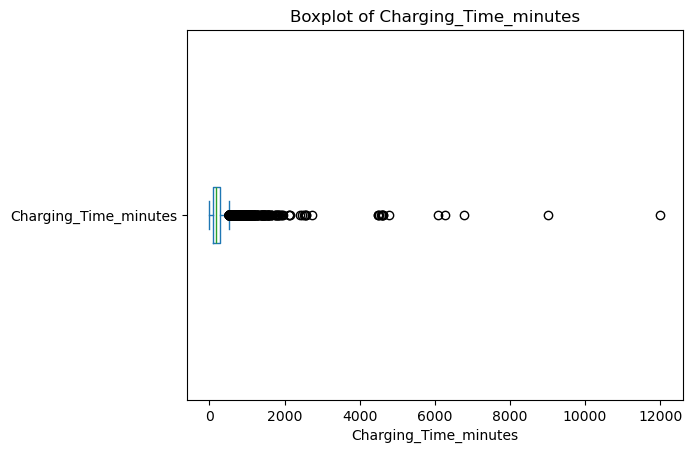

       Unnamed: 0                        id      connectionTime  \
6               6  5e23b149f9af8b5fe4b973d5 2020-01-02 14:09:14   
29             29  5e23b149f9af8b5fe4b973ec 2020-01-02 16:28:23   
81             81  5e28f766f9af8b70ebc91c98 2020-01-06 12:32:26   
83             83  5e28f766f9af8b70ebc91c9a 2020-01-06 12:48:56   
89             89  5e28f766f9af8b70ebc91ca0 2020-01-06 13:53:44   
...           ...                       ...                 ...   
66420       10058  5d574ad2f9af8b4c10c03639 2019-07-31 14:04:17   
66421       10059  5d574ad2f9af8b4c10c0363a 2019-07-31 14:05:20   
66425       10063  5d574ad2f9af8b4c10c0363e 2019-07-31 14:10:15   
66439       10077  5d574ad2f9af8b4c10c0364c 2019-07-31 14:45:02   
66442       10080  5d574ad2f9af8b4c10c0364f 2019-07-31 14:48:11   

           disconnectTime    doneChargingTime  kWhDelivered  \
6     2020-01-03 01:57:58 2020-01-03 00:59:21        43.477   
29    2020-01-03 03:10:07 2020-01-03 02:46:22        12.082   
81    

In [1005]:
plot_outliers('Charging_Time_minutes')

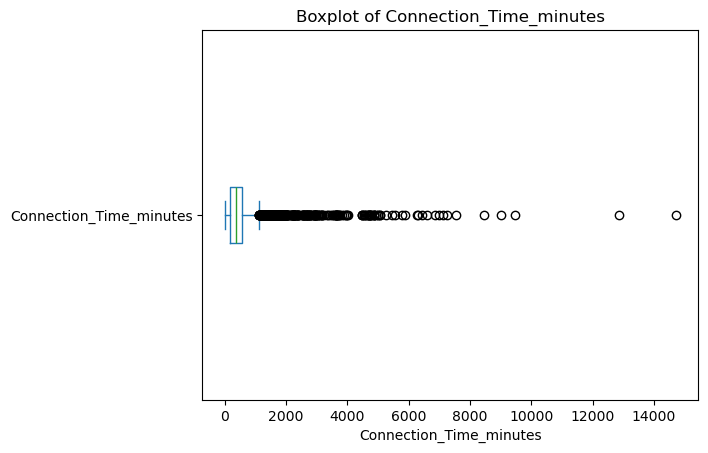

       Unnamed: 0                        id      connectionTime  \
7246         1673  5d5f33d2f9af8b650c8bfe56 2019-08-07 01:12:26   
7627         2054  5d69bfebf9af8b0682723ef7 2019-08-14 13:00:40   
7911         2338  5d71a8d8f9af8b435820d055 2019-08-20 14:20:30   
8960         3387  5d8d585ff9af8b2ac272ab86 2019-09-11 00:33:34   
11091        5518  5dc4c574f9af8b0159f31844 2019-10-22 23:35:50   
...           ...                       ...                 ...   
61169        4807  5cca3a54f9af8b49aaa4cbee 2019-04-16 00:01:28   
62402        6040  5ce88ce2f9af8b5b259d72f2 2019-05-09 00:09:47   
62651        6289  5cf075ecf9af8b74808d8308 2019-05-14 14:48:06   
63029        6667  5cf85ee3f9af8b11f3749cbe 2019-05-21 00:10:00   
64086        7724  5d16b161f9af8b7bdb8babc7 2019-06-12 13:38:35   

           disconnectTime    doneChargingTime  kWhDelivered  \
7246  2019-08-08 00:03:44 2019-08-07 10:11:52        57.217   
7627  2019-08-16 02:24:39 2019-08-14 14:48:08         4.557   
7911  

In [1006]:
plot_outliers('Connection_Time_minutes')

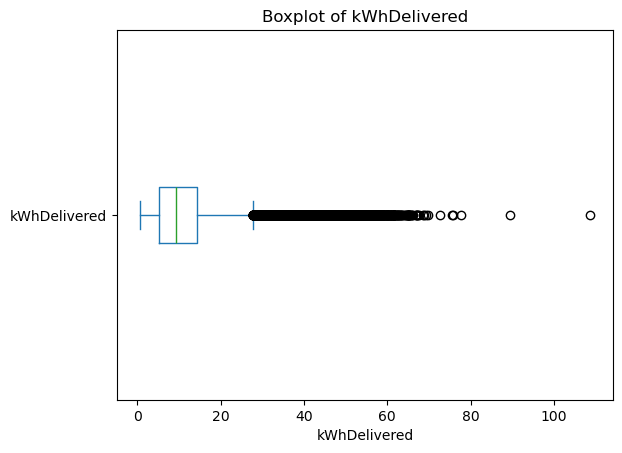

       Unnamed: 0                        id      connectionTime  \
1               1  5e23b149f9af8b5fe4b973d0 2020-01-02 13:36:50   
6               6  5e23b149f9af8b5fe4b973d5 2020-01-02 14:09:14   
7               7  5e23b149f9af8b5fe4b973d6 2020-01-02 14:17:32   
13             13  5e23b149f9af8b5fe4b973dc 2020-01-02 15:15:27   
21             21  5e23b149f9af8b5fe4b973e4 2020-01-02 15:30:19   
...           ...                       ...                 ...   
66425       10063  5d574ad2f9af8b4c10c0363e 2019-07-31 14:10:15   
66428       10066  5d574ad2f9af8b4c10c03641 2019-07-31 14:30:47   
66433       10071  5d574ad2f9af8b4c10c03646 2019-07-31 14:38:24   
66440       10078  5d574ad2f9af8b4c10c0364d 2019-07-31 14:45:29   
66445       10083  5d574ad2f9af8b4c10c03652 2019-07-31 18:08:04   

           disconnectTime    doneChargingTime  kWhDelivered  \
1     2020-01-02 22:38:21 2020-01-02 20:18:05        33.097   
6     2020-01-03 01:57:58 2020-01-03 00:59:21        43.477   
7     

In [1007]:
plot_outliers('kWhDelivered')

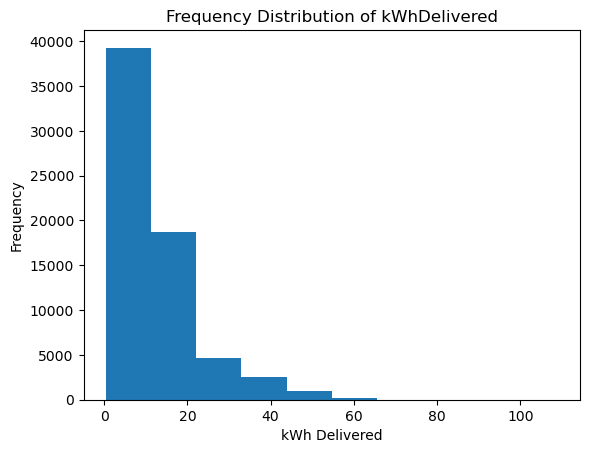

In [1008]:
plt.hist(new_df['kWhDelivered'])
plt.title('Frequency Distribution of kWhDelivered')
plt.xlabel('kWh Delivered')
plt.ylabel('Frequency')
plt.show()

In [1009]:
Q1_kWh = new_df['kWhDelivered'].quantile(0.25)
Q3_kWh = new_df['kWhDelivered'].quantile(0.75)
IQR_kWh = Q3_kWh - Q1_kWh
lower_bound_kWh = Q1_kWh - 1.5 * IQR_kWh
upper_bound_kWh = Q3_kWh + 1.5 * IQR_kWh
outliers_kWh = new_df[(new_df['kWhDelivered'] < lower_bound_kWh)|(new_df['kWhDelivered'] > upper_bound_kWh)]
print(outliers_kWh)

       Unnamed: 0                        id      connectionTime  \
1               1  5e23b149f9af8b5fe4b973d0 2020-01-02 13:36:50   
6               6  5e23b149f9af8b5fe4b973d5 2020-01-02 14:09:14   
7               7  5e23b149f9af8b5fe4b973d6 2020-01-02 14:17:32   
13             13  5e23b149f9af8b5fe4b973dc 2020-01-02 15:15:27   
21             21  5e23b149f9af8b5fe4b973e4 2020-01-02 15:30:19   
...           ...                       ...                 ...   
66425       10063  5d574ad2f9af8b4c10c0363e 2019-07-31 14:10:15   
66428       10066  5d574ad2f9af8b4c10c03641 2019-07-31 14:30:47   
66433       10071  5d574ad2f9af8b4c10c03646 2019-07-31 14:38:24   
66440       10078  5d574ad2f9af8b4c10c0364d 2019-07-31 14:45:29   
66445       10083  5d574ad2f9af8b4c10c03652 2019-07-31 18:08:04   

           disconnectTime    doneChargingTime  kWhDelivered  \
1     2020-01-02 22:38:21 2020-01-02 20:18:05        33.097   
6     2020-01-03 01:57:58 2020-01-03 00:59:21        43.477   
7     

In [1010]:
print("\nStatisitcal Summary:")
print(outliers_kWh.describe())


Statisitcal Summary:
         Unnamed: 0                 connectionTime  \
count   5751.000000                           5751   
mean    4156.843679  2019-11-09 08:05:01.848721920   
min        0.000000            2018-04-25 16:25:51   
25%     1653.000000     2019-03-22 13:23:02.500000   
50%     3556.000000            2019-08-29 14:35:02   
75%     5936.000000            2020-02-27 18:54:45   
max    15289.000000            2021-09-14 05:43:39   
std     3145.383383                            NaN   

                      disconnectTime               doneChargingTime  \
count                           5751                           5751   
mean   2019-11-09 16:48:20.922796032  2019-11-09 15:03:19.655190528   
min              2018-04-25 22:30:46            2018-04-25 22:30:41   
25%       2019-03-22 19:58:29.500000     2019-03-22 19:58:20.500000   
50%              2019-08-30 00:23:23            2019-08-29 23:49:56   
75%       2020-02-28 02:55:08.500000            2020-02-28 02:00:

## Delete unnecessary columns

In [1011]:
charging_df = new_df.drop(columns=['Connection_Time','Charging_Time','Idle_Time','Unnamed: 0'])

In [1012]:
charging_df.head(25)

,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,userID,userInputs,Connection_Time_minutes,Charging_Time_minutes,Idle_Time_minutes
0,5e23b149f9af8b5fe4b973cf,2020-01-02 13:08:54,2020-01-02 19:11:15,2020-01-02 17:31:35,25.016,1_1_179_810_2020-01-02 13:08:53.870034,1,AG-3F30,1-1-179-810,America/Los_Angeles,194.0,"[{'WhPerMile': 250, 'kWhRequested': 25.0, 'mil...",362.350000,262.683333,99.666667
1,5e23b149f9af8b5fe4b973d0,2020-01-02 13:36:50,2020-01-02 22:38:21,2020-01-02 20:18:05,33.097,1_1_193_825_2020-01-02 13:36:49.599853,1,AG-1F01,1-1-193-825,America/Los_Angeles,4275.0,"[{'WhPerMile': 280, 'kWhRequested': 70.0, 'mil...",541.516667,401.250000,140.266667
2,5e23b149f9af8b5fe4b973d1,2020-01-02 13:56:35,2020-01-03 00:39:22,2020-01-02 16:35:06,6.521,1_1_193_829_2020-01-02 13:56:35.214993,1,AG-1F03,1-1-193-829,America/Los_Angeles,344.0,"[{'WhPerMile': 400, 'kWhRequested': 8.0, 'mile...",642.783333,158.516667,484.266667
3,5e23b149f9af8b5fe4b973d2,2020-01-02 13:59:58,2020-01-02 16:38:39,2020-01-02 15:18:45,2.355,1_1_193_820_2020-01-02 13:59:58.309319,1,AG-1F04,1-1-193-820,America/Los_Angeles,1117.0,"[{'WhPerMile': 400, 'kWhRequested': 8.0, 'mile...",158.683333,78.783333,79.900000
4,5e23b149f9af8b5fe4b973d3,2020-01-02 14:00:01,2020-01-02 22:08:40,2020-01-02 18:17:30,13.375,1_1_193_819_2020-01-02 14:00:00.779967,1,AG-1F06,1-1-193-819,America/Los_Angeles,334.0,"[{'WhPerMile': 400, 'kWhRequested': 16.0, 'mil...",488.650000,257.483333,231.166667
5,5e23b149f9af8b5fe4b973d4,2020-01-02 14:00:13,2020-01-02 23:00:41,2020-01-02 20:13:21,13.370,1_1_194_821_2020-01-02 14:00:05.241573,1,AG-1F13,1-1-194-821,America/Los_Angeles,3519.0,"[{'WhPerMile': 600, 'kWhRequested': 24.0, 'mil...",540.466667,373.133333,167.333333
6,5e23b149f9af8b5fe4b973d5,2020-01-02 14:09:14,2020-01-03 01:57:58,2020-01-03 00:59:21,43.477,1_1_178_817_2020-01-02 14:09:14.451827,1,AG-1F09,1-1-178-817,America/Los_Angeles,933.0,"[{'WhPerMile': 385, 'kWhRequested': 65.45, 'mi...",708.733333,650.116667,58.616667
7,5e23b149f9af8b5fe4b973d6,2020-01-02 14:17:32,2020-01-03 00:44:54,2020-01-02 20:22:40,32.441,1_1_191_804_2020-01-02 14:17:32.329535,1,AG-4F34,1-1-191-804,America/Los_Angeles,3737.0,"[{'WhPerMile': 300, 'kWhRequested': 45.0, 'mil...",627.366667,365.133333,262.233333
8,5e23b149f9af8b5fe4b973d7,2020-01-02 14:25:38,2020-01-02 19:36:05,2020-01-02 18:38:39,13.264,1_1_194_826_2020-01-02 14:25:37.578692,1,AG-1F11,1-1-194-826,America/Los_Angeles,419.0,"[{'WhPerMile': 400, 'kWhRequested': 40.0, 'mil...",310.450000,253.016667,57.433333
9,5e23b149f9af8b5fe4b973d8,2020-01-02 14:27:40,2020-01-02 20:01:48,2020-01-02 19:17:46,13.285,1_1_178_823_2020-01-02 14:27:39.582337,1,AG-1F08,1-1-178-823,America/Los_Angeles,651.0,"[{'WhPerMile': 400, 'kWhRequested': 20.0, 'mil...",334.133333,290.100000,44.033333


# Different way of filling doneChargingTime missing value(from PENG)

### handle userID and userInputs

In [1013]:
charging_2=charging.copy()
charging_2 = charging_2.drop(columns=['userID'])

In [1014]:
import  ast

In [1015]:
# Define a function to parse the userInputs column.
def parse_user_inputs(user_inputs):
    if pd.isna(user_inputs) or user_inputs == '':
        return {}
    try:
        # Convert a string to a dictionary.
        parsed_data = ast.literal_eval(user_inputs)
        if isinstance(parsed_data, list):
            parsed_data = parsed_data[0]
        return parsed_data
    except (ValueError, SyntaxError):
        return {}

In [1016]:
user_inputs_df = charging_2['userInputs'].apply(parse_user_inputs).apply(pd.Series)
charging_2 = pd.concat([charging_2.drop(columns=['userInputs']), user_inputs_df], axis=1)
charging_2

,Unnamed: 0,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,WhPerMile,kWhRequested,milesRequested,minutesAvailable,modifiedAt,paymentRequired,requestedDeparture,userID
0,0,5e23b149f9af8b5fe4b973cf,2020-01-02 13:08:54+00:00,2020-01-02 19:11:15+00:00,2020-01-02 17:31:35+00:00,25.016,1_1_179_810_2020-01-02 13:08:53.870034,1,AG-3F30,1-1-179-810,America/Los_Angeles,250.0,25.00,100.0,463.0,"Thu, 02 Jan 2020 13:09:39 GMT",True,"Thu, 02 Jan 2020 20:51:54 GMT",194.0
1,1,5e23b149f9af8b5fe4b973d0,2020-01-02 13:36:50+00:00,2020-01-02 22:38:21+00:00,2020-01-02 20:18:05+00:00,33.097,1_1_193_825_2020-01-02 13:36:49.599853,1,AG-1F01,1-1-193-825,America/Los_Angeles,280.0,70.00,250.0,595.0,"Thu, 02 Jan 2020 13:37:11 GMT",True,"Thu, 02 Jan 2020 23:31:50 GMT",4275.0
2,2,5e23b149f9af8b5fe4b973d1,2020-01-02 13:56:35+00:00,2020-01-03 00:39:22+00:00,2020-01-02 16:35:06+00:00,6.521,1_1_193_829_2020-01-02 13:56:35.214993,1,AG-1F03,1-1-193-829,America/Los_Angeles,400.0,8.00,20.0,60.0,"Thu, 02 Jan 2020 13:57:17 GMT",True,"Thu, 02 Jan 2020 14:56:35 GMT",344.0
3,3,5e23b149f9af8b5fe4b973d2,2020-01-02 13:59:58+00:00,2020-01-02 16:38:39+00:00,2020-01-02 15:18:45+00:00,2.355,1_1_193_820_2020-01-02 13:59:58.309319,1,AG-1F04,1-1-193-820,America/Los_Angeles,400.0,8.00,20.0,65.0,"Thu, 02 Jan 2020 14:00:03 GMT",True,"Thu, 02 Jan 2020 15:04:58 GMT",1117.0
4,4,5e23b149f9af8b5fe4b973d3,2020-01-02 14:00:01+00:00,2020-01-02 22:08:40+00:00,2020-01-02 18:17:30+00:00,13.375,1_1_193_819_2020-01-02 14:00:00.779967,1,AG-1F06,1-1-193-819,America/Los_Angeles,400.0,16.00,40.0,504.0,"Thu, 02 Jan 2020 14:00:13 GMT",True,"Thu, 02 Jan 2020 22:24:01 GMT",334.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66445,10083,5d574ad2f9af8b4c10c03652,2019-07-31 18:08:04+00:00,2019-07-31 23:29:18+00:00,2019-07-31 23:30:18+00:00,28.787,1_1_179_809_2019-07-31 18:08:04.432654,1,AG-3F27,1-1-179-809,America/Los_Angeles,240.0,31.20,130.0,355.0,"Wed, 31 Jul 2019 18:08:23 GMT",True,"Thu, 01 Aug 2019 00:03:04 GMT",393.0
66446,10084,5d574ad2f9af8b4c10c03653,2019-07-31 18:40:41+00:00,2019-08-01 00:59:42+00:00,2019-07-31 21:44:23+00:00,7.787,1_1_179_810_2019-07-31 18:40:40.900203,1,AG-3F30,1-1-179-810,America/Los_Angeles,333.0,6.66,20.0,455.0,"Wed, 31 Jul 2019 18:41:02 GMT",True,"Thu, 01 Aug 2019 02:15:41 GMT",220.0
66447,10085,5d574ad2f9af8b4c10c03654,2019-07-31 19:04:40+00:00,2019-07-31 22:44:22+00:00,2019-07-31 22:45:21+00:00,11.274,1_1_191_795_2019-07-31 19:04:40.098273,1,AG-4F51,1-1-191-795,America/Los_Angeles,333.0,19.98,60.0,184.0,"Wed, 31 Jul 2019 19:04:57 GMT",True,"Wed, 31 Jul 2019 22:08:40 GMT",1974.0
66448,10086,5d574ad2f9af8b4c10c03655,2019-07-31 19:19:47+00:00,2019-08-01 00:34:51+00:00,2019-07-31 21:25:30+00:00,11.589,1_1_191_778_2019-07-31 19:19:46.919358,1,AG-4F43,1-1-191-778,America/Los_Angeles,275.0,22.00,80.0,60.0,"Wed, 31 Jul 2019 19:20:10 GMT",True,"Wed, 31 Jul 2019 20:19:47 GMT",942.0


In [1017]:
charging_2['userID'] = charging_2['userID'].fillna(value=-1)
charging_2.head(25)

,Unnamed: 0,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,WhPerMile,kWhRequested,milesRequested,minutesAvailable,modifiedAt,paymentRequired,requestedDeparture,userID
0,0,5e23b149f9af8b5fe4b973cf,2020-01-02 13:08:54+00:00,2020-01-02 19:11:15+00:00,2020-01-02 17:31:35+00:00,25.016,1_1_179_810_2020-01-02 13:08:53.870034,1,AG-3F30,1-1-179-810,America/Los_Angeles,250.0,25.00,100.0,463.0,"Thu, 02 Jan 2020 13:09:39 GMT",True,"Thu, 02 Jan 2020 20:51:54 GMT",194.0
1,1,5e23b149f9af8b5fe4b973d0,2020-01-02 13:36:50+00:00,2020-01-02 22:38:21+00:00,2020-01-02 20:18:05+00:00,33.097,1_1_193_825_2020-01-02 13:36:49.599853,1,AG-1F01,1-1-193-825,America/Los_Angeles,280.0,70.00,250.0,595.0,"Thu, 02 Jan 2020 13:37:11 GMT",True,"Thu, 02 Jan 2020 23:31:50 GMT",4275.0
2,2,5e23b149f9af8b5fe4b973d1,2020-01-02 13:56:35+00:00,2020-01-03 00:39:22+00:00,2020-01-02 16:35:06+00:00,6.521,1_1_193_829_2020-01-02 13:56:35.214993,1,AG-1F03,1-1-193-829,America/Los_Angeles,400.0,8.00,20.0,60.0,"Thu, 02 Jan 2020 13:57:17 GMT",True,"Thu, 02 Jan 2020 14:56:35 GMT",344.0
3,3,5e23b149f9af8b5fe4b973d2,2020-01-02 13:59:58+00:00,2020-01-02 16:38:39+00:00,2020-01-02 15:18:45+00:00,2.355,1_1_193_820_2020-01-02 13:59:58.309319,1,AG-1F04,1-1-193-820,America/Los_Angeles,400.0,8.00,20.0,65.0,"Thu, 02 Jan 2020 14:00:03 GMT",True,"Thu, 02 Jan 2020 15:04:58 GMT",1117.0
4,4,5e23b149f9af8b5fe4b973d3,2020-01-02 14:00:01+00:00,2020-01-02 22:08:40+00:00,2020-01-02 18:17:30+00:00,13.375,1_1_193_819_2020-01-02 14:00:00.779967,1,AG-1F06,1-1-193-819,America/Los_Angeles,400.0,16.00,40.0,504.0,"Thu, 02 Jan 2020 14:00:13 GMT",True,"Thu, 02 Jan 2020 22:24:01 GMT",334.0
5,5,5e23b149f9af8b5fe4b973d4,2020-01-02 14:00:13+00:00,2020-01-02 23:00:41+00:00,2020-01-02 20:13:21+00:00,13.370,1_1_194_821_2020-01-02 14:00:05.241573,1,AG-1F13,1-1-194-821,America/Los_Angeles,600.0,24.00,40.0,624.0,"Thu, 02 Jan 2020 14:00:12 GMT",True,"Fri, 03 Jan 2020 00:24:13 GMT",3519.0
6,6,5e23b149f9af8b5fe4b973d5,2020-01-02 14:09:14+00:00,2020-01-03 01:57:58+00:00,2020-01-03 00:59:21+00:00,43.477,1_1_178_817_2020-01-02 14:09:14.451827,1,AG-1F09,1-1-178-817,America/Los_Angeles,385.0,65.45,170.0,647.0,"Thu, 02 Jan 2020 14:09:33 GMT",True,"Fri, 03 Jan 2020 00:56:14 GMT",933.0
7,7,5e23b149f9af8b5fe4b973d6,2020-01-02 14:17:32+00:00,2020-01-03 00:44:54+00:00,2020-01-02 20:22:40+00:00,32.441,1_1_191_804_2020-01-02 14:17:32.329535,1,AG-4F34,1-1-191-804,America/Los_Angeles,300.0,45.00,150.0,126.0,"Thu, 02 Jan 2020 14:17:40 GMT",True,"Thu, 02 Jan 2020 16:23:32 GMT",3737.0
8,8,5e23b149f9af8b5fe4b973d7,2020-01-02 14:25:38+00:00,2020-01-02 19:36:05+00:00,2020-01-02 18:38:39+00:00,13.264,1_1_194_826_2020-01-02 14:25:37.578692,1,AG-1F11,1-1-194-826,America/Los_Angeles,400.0,40.00,100.0,491.0,"Thu, 02 Jan 2020 14:25:45 GMT",True,"Thu, 02 Jan 2020 22:36:38 GMT",419.0
9,9,5e23b149f9af8b5fe4b973d8,2020-01-02 14:27:40+00:00,2020-01-02 20:01:48+00:00,2020-01-02 19:17:46+00:00,13.285,1_1_178_823_2020-01-02 14:27:39.582337,1,AG-1F08,1-1-178-823,America/Los_Angeles,400.0,20.00,50.0,226.0,"Thu, 02 Jan 2020 14:27:48 GMT",True,"Thu, 02 Jan 2020 18:13:40 GMT",651.0


In [1018]:
charging_2['WhPerMile'] = charging_2['WhPerMile'].fillna(value="unkown")
charging_2['kWhRequested'] = charging_2['kWhRequested'].fillna(value="unkown")
charging_2['milesRequested'] = charging_2['milesRequested'].fillna(value="unkown")
charging_2['minutesAvailable'] = charging_2['minutesAvailable'].fillna(value="unkown")
charging_2['modifiedAt'] = charging_2['modifiedAt'].fillna(value="unkown")
charging_2['paymentRequired'] = charging_2['paymentRequired'].fillna(value="unkown")
charging_2['requestedDeparture'] = charging_2['requestedDeparture'].fillna(value="unkown")

In [1019]:
charging_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66450 entries, 0 to 66449
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          66450 non-null  int64  
 1   id                  66450 non-null  object 
 2   connectionTime      66450 non-null  object 
 3   disconnectTime      66450 non-null  object 
 4   doneChargingTime    62362 non-null  object 
 5   kWhDelivered        66450 non-null  float64
 6   sessionID           66450 non-null  object 
 7   siteID              66450 non-null  int64  
 8   spaceID             66450 non-null  object 
 9   stationID           66450 non-null  object 
 10  timezone            66450 non-null  object 
 11  WhPerMile           66450 non-null  object 
 12  kWhRequested        66450 non-null  object 
 13  milesRequested      66450 non-null  object 
 14  minutesAvailable    66450 non-null  object 
 15  modifiedAt          66450 non-null  object 
 16  paym

In [1020]:
charging_2['connectionTime'] = pd.to_datetime(charging_2['connectionTime'])
charging_2['doneChargingTime'] = pd.to_datetime(charging_2['doneChargingTime'])
charging_2['disconnectTime'] = pd.to_datetime(charging_2['disconnectTime'])
charging_2['disconnectTime'] = pd.to_datetime(charging_2['requestedDeparture'])
charging_2['connectionTime'] = pd.to_datetime(charging_2['connectionTime']).dt.tz_localize(None)
charging_2['disconnectTime'] = pd.to_datetime(charging_2['disconnectTime']).dt.tz_localize(None)

ValueError: time data "unkown" doesn't match format "%a, %d %b %Y %H:%M:%S GMT", at position 11. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [960]:
filtered_df = charging_2[(charging_2['doneChargingTime'].isnull()) & (charging_2['userID'] != -1)]
filtered_df.head(25)

,Unnamed: 0,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,WhPerMile,kWhRequested,milesRequested,minutesAvailable,modifiedAt,paymentRequired,requestedDeparture,userID
3756,3756,5ea3848df9af8b428bf97225,2020-04-08 16:36:53+00:00,2020-04-09 03:43:29+00:00,NaN,25.183,1_1_194_822_2020-04-08 16:36:53.316264,1,AG-1F12,1-1-194-822,America/Los_Angeles,250.0,75.00,300.0,720.0,"Wed, 08 Apr 2020 16:37:01 GMT",True,"Thu, 09 Apr 2020 04:36:53 GMT",507.0
3757,3757,5ea4d60df9af8b46573f1ee7,2020-04-09 13:23:52+00:00,2020-04-09 17:59:02+00:00,NaN,14.136,1_1_193_827_2020-04-09 13:23:51.689520,1,AG-1F02,1-1-193-827,America/Los_Angeles,400.0,40.00,100.0,479.0,"Thu, 09 Apr 2020 13:24:06 GMT",True,"Thu, 09 Apr 2020 21:22:52 GMT",419.0
3758,3758,5ea4d60df9af8b46573f1ee8,2020-04-09 13:40:03+00:00,2020-04-09 21:43:22+00:00,NaN,14.203,1_1_178_823_2020-04-09 13:39:55.115497,1,AG-1F08,1-1-178-823,America/Los_Angeles,400.0,24.00,60.0,483.0,"Thu, 09 Apr 2020 13:40:03 GMT",True,"Thu, 09 Apr 2020 21:43:03 GMT",5065.0
3759,3759,5ea4d60df9af8b46573f1ee9,2020-04-09 14:01:53+00:00,2020-04-09 16:33:40+00:00,NaN,13.041,1_1_178_828_2020-04-09 14:01:53.467693,1,AG-1F10,1-1-178-828,America/Los_Angeles,400.0,20.00,50.0,183.0,"Thu, 09 Apr 2020 14:02:09 GMT",True,"Thu, 09 Apr 2020 17:04:53 GMT",651.0
3760,3760,5ea4d60df9af8b46573f1eea,2020-04-09 15:01:06+00:00,2020-04-09 23:38:08+00:00,NaN,5.797,1_1_193_820_2020-04-09 15:01:06.343454,1,AG-1F04,1-1-193-820,America/Los_Angeles,300.0,6.00,20.0,182.0,"Thu, 09 Apr 2020 15:01:20 GMT",True,"Thu, 09 Apr 2020 18:03:06 GMT",466.0
3761,3761,5ea4d60df9af8b46573f1eeb,2020-04-09 19:58:23+00:00,2020-04-10 01:59:05+00:00,NaN,12.020,1_1_194_822_2020-04-09 19:58:22.689671,1,AG-1F12,1-1-194-822,America/Los_Angeles,400.0,12.00,30.0,61.0,"Thu, 09 Apr 2020 19:59:00 GMT",True,"Thu, 09 Apr 2020 20:59:23 GMT",413.0
3762,3762,5ea4d60df9af8b46573f1eec,2020-04-09 21:34:30+00:00,2020-04-10 00:41:31+00:00,NaN,15.335,1_1_179_800_2020-04-09 21:34:29.748681,1,AG-3F32,1-1-179-800,America/Los_Angeles,600.0,24.00,40.0,61.0,"Thu, 09 Apr 2020 21:35:01 GMT",True,"Thu, 09 Apr 2020 22:35:30 GMT",5015.0
3763,3763,5ea6278df9af8b4a2e7bd22a,2020-04-10 13:17:59+00:00,2020-04-10 13:49:37+00:00,NaN,3.160,1_1_178_828_2020-04-10 13:17:59.102045,1,AG-1F10,1-1-178-828,America/Los_Angeles,400.0,20.00,50.0,183.0,"Fri, 10 Apr 2020 13:18:09 GMT",True,"Fri, 10 Apr 2020 16:20:59 GMT",651.0
3764,3764,5ea6278df9af8b4a2e7bd22b,2020-04-10 14:51:28+00:00,2020-04-10 23:50:23+00:00,NaN,2.828,1_1_193_819_2020-04-10 14:51:27.842475,1,AG-1F06,1-1-193-819,America/Los_Angeles,300.0,9.00,30.0,511.0,"Fri, 10 Apr 2020 14:51:34 GMT",True,"Fri, 10 Apr 2020 23:22:28 GMT",466.0
3765,3765,5ea6278df9af8b4a2e7bd22c,2020-04-10 14:55:07+00:00,2020-04-10 15:43:03+00:00,NaN,4.725,1_1_178_828_2020-04-10 14:55:07.466429,1,AG-1F10,1-1-178-828,America/Los_Angeles,400.0,20.00,50.0,183.0,"Fri, 10 Apr 2020 14:55:16 GMT",True,"Fri, 10 Apr 2020 17:58:07 GMT",651.0


In [961]:
filtered_df['connectionTime'] = pd.to_datetime(filtered_df['connectionTime']).dt.tz_localize(None)
filtered_df['disconnectTime'] = pd.to_datetime(filtered_df['disconnectTime']).dt.tz_localize(None)
filtered_df['estimate_donechargingTime'] = filtered_df['connectionTime'] + pd.to_timedelta(filtered_df['minutesAvailable'], unit='m')
filtered_df

C:\Users\zp\AppData\Local\Temp\ipykernel_21032\2733724761.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['connectionTime'] = pd.to_datetime(filtered_df['connectionTime']).dt.tz_localize(None)
C:\Users\zp\AppData\Local\Temp\ipykernel_21032\2733724761.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['disconnectTime'] = pd.to_datetime(filtered_df['disconnectTime']).dt.tz_localize(None)
C:\Users\zp\AppData\Local\Temp\ipykernel_21032\2733724761.py:3: SettingWithCopyWarning: 
A val

,Unnamed: 0,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,WhPerMile,kWhRequested,milesRequested,minutesAvailable,modifiedAt,paymentRequired,requestedDeparture,userID,estimate_donechargingTime
3756,3756,5ea3848df9af8b428bf97225,2020-04-08 16:36:53,2020-04-09 03:43:29,NaN,25.183,1_1_194_822_2020-04-08 16:36:53.316264,1,AG-1F12,1-1-194-822,America/Los_Angeles,250.0,75.00,300.0,720.0,"Wed, 08 Apr 2020 16:37:01 GMT",True,"Thu, 09 Apr 2020 04:36:53 GMT",507.0,2020-04-09 04:36:53
3757,3757,5ea4d60df9af8b46573f1ee7,2020-04-09 13:23:52,2020-04-09 17:59:02,NaN,14.136,1_1_193_827_2020-04-09 13:23:51.689520,1,AG-1F02,1-1-193-827,America/Los_Angeles,400.0,40.00,100.0,479.0,"Thu, 09 Apr 2020 13:24:06 GMT",True,"Thu, 09 Apr 2020 21:22:52 GMT",419.0,2020-04-09 21:22:52
3758,3758,5ea4d60df9af8b46573f1ee8,2020-04-09 13:40:03,2020-04-09 21:43:22,NaN,14.203,1_1_178_823_2020-04-09 13:39:55.115497,1,AG-1F08,1-1-178-823,America/Los_Angeles,400.0,24.00,60.0,483.0,"Thu, 09 Apr 2020 13:40:03 GMT",True,"Thu, 09 Apr 2020 21:43:03 GMT",5065.0,2020-04-09 21:43:03
3759,3759,5ea4d60df9af8b46573f1ee9,2020-04-09 14:01:53,2020-04-09 16:33:40,NaN,13.041,1_1_178_828_2020-04-09 14:01:53.467693,1,AG-1F10,1-1-178-828,America/Los_Angeles,400.0,20.00,50.0,183.0,"Thu, 09 Apr 2020 14:02:09 GMT",True,"Thu, 09 Apr 2020 17:04:53 GMT",651.0,2020-04-09 17:04:53
3760,3760,5ea4d60df9af8b46573f1eea,2020-04-09 15:01:06,2020-04-09 23:38:08,NaN,5.797,1_1_193_820_2020-04-09 15:01:06.343454,1,AG-1F04,1-1-193-820,America/Los_Angeles,300.0,6.00,20.0,182.0,"Thu, 09 Apr 2020 15:01:20 GMT",True,"Thu, 09 Apr 2020 18:03:06 GMT",466.0,2020-04-09 18:03:06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60411,4049,5cb3d2a8f9af8b4551261e75,2019-03-30 00:32:10,2019-03-30 02:23:14,NaN,11.148,1_1_193_829_2019-03-30 00:32:10.128651,1,AG-1F03,1-1-193-829,America/Los_Angeles,400.0,24.00,60.0,137.0,"Sat, 30 Mar 2019 00:32:57 GMT",True,"Sat, 30 Mar 2019 02:49:10 GMT",194.0,2019-03-30 02:49:10
61097,4735,5cc8e891f9af8b45d975b819,2019-04-14 16:19:12,2019-04-14 20:38:39,NaN,11.678,1_1_193_816_2019-04-14 16:19:11.864262,1,AG-1F05,1-1-193-816,America/Los_Angeles,400.0,56.00,140.0,222.0,"Sun, 14 Apr 2019 16:19:34 GMT",True,"Sun, 14 Apr 2019 20:01:12 GMT",364.0,2019-04-14 20:01:12
61103,4741,5cca3a54f9af8b49aaa4cbac,2019-04-15 13:00:59,2019-04-15 13:55:25,NaN,3.343,1_1_193_819_2019-04-15 13:00:58.722284,1,AG-1F06,1-1-193-819,America/Los_Angeles,400.0,20.00,50.0,158.0,"Mon, 15 Apr 2019 13:01:13 GMT",True,"Mon, 15 Apr 2019 15:38:59 GMT",651.0,2019-04-15 15:38:59
61117,4755,5cca3a54f9af8b49aaa4cbba,2019-04-15 13:52:45,2019-04-15 14:47:01,NaN,4.558,1_1_179_800_2019-04-15 13:52:44.693153,1,AG-3F32,1-1-179-800,America/Los_Angeles,400.0,12.00,30.0,77.0,"Mon, 15 Apr 2019 13:53:15 GMT",True,"Mon, 15 Apr 2019 15:09:45 GMT",194.0,2019-04-15 15:09:45


In [962]:
filtered_df['doneChargingTime'] = filtered_df['doneChargingTime'].fillna(filtered_df[['estimate_donechargingTime', 'disconnectTime']].min(axis=1))

C:\Users\zp\AppData\Local\Temp\ipykernel_21032\13296082.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  filtered_df['doneChargingTime'] = filtered_df['doneChargingTime'].fillna(filtered_df[['estimate_donechargingTime', 'disconnectTime']].min(axis=1))
C:\Users\zp\AppData\Local\Temp\ipykernel_21032\13296082.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['doneChargingTime'] = filtered_df['doneChargingTime'].fillna(filtered_df[['estimate_donechargingTime', 'disconnectTime']].min(axis=1))


In [964]:
filtered_df.drop(columns=['estimate_donechargingTime'], inplace=True)

C:\Users\zp\AppData\Local\Temp\ipykernel_21032\162201093.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df.drop(columns=['estimate_donechargingTime'], inplace=True)


In [965]:
charging_2['doneChargingTime'].update(filtered_df['doneChargingTime'])

## ## Merge data using connectionTime as the key(Different from Xiaofeng's method)

In [191]:
weather['timestamp'].describe()
#the data start form 2018-01-01 08:53:00 to 2021-01-01 07:53:00

count                   29244
unique                  29244
top       2018-01-01 08:53:00
freq                        1
Name: timestamp, dtype: object

In [192]:
# convert a timestamp format
weather['timestamp'] = pd.to_datetime(weather['timestamp'])
weather.set_index('timestamp', inplace=True)

In [193]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 66423 entries, 0 to 66449
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype          
---  ------                   --------------  -----          
 0   Unnamed: 0               66423 non-null  int64          
 1   id                       66423 non-null  object         
 2   connectionTime           66423 non-null  datetime64[ns] 
 3   disconnectTime           66423 non-null  datetime64[ns] 
 4   doneChargingTime         66423 non-null  datetime64[ns] 
 5   kWhDelivered             66423 non-null  float64        
 6   sessionID                66423 non-null  object         
 7   siteID                   66423 non-null  int64          
 8   spaceID                  66423 non-null  object         
 9   stationID                66423 non-null  object         
 10  timezone                 66423 non-null  object         
 11  userID                   66423 non-null  float64        
 12  userInputs             

In [122]:
charging['connectionTime'] = pd.to_datetime(charging['connectionTime'])

In [123]:
charging['connectionTime'].describe()
#the data start form 2018-04-25 11:08:04+00:00 to 2021-09-14 05:43:39+00:00
#There is missing weather data from January 1, 2021, 7:53 AM to September 14, 2021, 5:43:39 AM. 

count                                  66450
mean     2019-08-06 20:19:01.997832704+00:00
min                2018-04-25 11:08:04+00:00
25%         2018-11-13 08:28:56.500000+00:00
50%         2019-06-14 14:17:45.500000+00:00
75%         2020-01-08 00:31:54.500000+00:00
max                2021-09-14 05:43:39+00:00
Name: connectionTime, dtype: object

In [124]:
start_date = '2020-01-01 07:53:05'
end_date = '2020-09-14 05:43:39'
reference_time=weather.loc[start_date:end_date]
reference_time.index=reference_time.index+pd.DateOffset(years=1)
reference_time.head(25)

,temperature,cloud_cover,cloud_cover_description,pressure,windspeed,precipitation
timestamp,,,,,,
2021-01-01 08:53:00,9.0,33.0,Fair,989.77,11.0,0.0
2021-01-01 09:53:00,11.0,33.0,Fair,990.10,6.0,0.0
2021-01-01 10:53:00,9.0,29.0,Partly Cloudy,990.10,0.0,0.0
2021-01-01 11:53:00,8.0,29.0,Partly Cloudy,989.11,0.0,0.0
2021-01-01 12:53:00,7.0,29.0,Partly Cloudy,989.77,0.0,0.0
2021-01-01 13:53:00,7.0,33.0,Fair,989.44,0.0,0.0
2021-01-01 14:53:00,7.0,34.0,Fair,989.44,6.0,0.0
2021-01-01 15:53:00,8.0,34.0,Fair,989.77,7.0,0.0
2021-01-01 16:53:00,12.0,30.0,Partly Cloudy,990.76,9.0,0.0


In [125]:
weather_full=pd.concat([weather,reference_time])
weather_full.index

DatetimeIndex(['2018-01-01 08:53:00', '2018-01-01 09:53:00',
               '2018-01-01 10:53:00', '2018-01-01 11:53:00',
               '2018-01-01 12:53:00', '2018-01-01 13:53:00',
               '2018-01-01 14:53:00', '2018-01-01 15:53:00',
               '2018-01-01 16:53:00', '2018-01-01 17:53:00',
               ...
               '2021-09-13 20:02:00', '2021-09-13 20:53:00',
               '2021-09-13 21:53:00', '2021-09-13 22:53:00',
               '2021-09-13 23:53:00', '2021-09-14 00:53:00',
               '2021-09-14 01:53:00', '2021-09-14 02:53:00',
               '2021-09-14 03:53:00', '2021-09-14 04:53:00'],
              dtype='datetime64[ns]', name='timestamp', length=36070, freq=None)

In [126]:
missing(weather_full)

,missing_number,missing_percent
temperature,0,0.0
cloud_cover,0,0.0
cloud_cover_description,0,0.0
pressure,0,0.0
windspeed,0,0.0
precipitation,0,0.0
total,0,0.0


In [127]:
charging['time']=charging['connectionTime']
charging['time']=pd.to_datetime(charging['time'])
charging=charging.set_index('time')
print(charging.index)
#This time includes a timezone(UTC).

DatetimeIndex(['2020-01-02 13:08:54+00:00', '2020-01-02 13:36:50+00:00',
               '2020-01-02 13:56:35+00:00', '2020-01-02 13:59:58+00:00',
               '2020-01-02 14:00:01+00:00', '2020-01-02 14:00:13+00:00',
               '2020-01-02 14:09:14+00:00', '2020-01-02 14:17:32+00:00',
               '2020-01-02 14:25:38+00:00', '2020-01-02 14:27:40+00:00',
               ...
               '2019-07-31 14:45:29+00:00', '2019-07-31 14:46:58+00:00',
               '2019-07-31 14:48:11+00:00', '2019-07-31 14:50:02+00:00',
               '2019-07-31 14:50:17+00:00', '2019-07-31 18:08:04+00:00',
               '2019-07-31 18:40:41+00:00', '2019-07-31 19:04:40+00:00',
               '2019-07-31 19:19:47+00:00', '2019-07-31 19:21:47+00:00'],
              dtype='datetime64[ns, UTC]', name='time', length=66450, freq=None)


In [128]:
charging['timezone'].unique()

array(['America/Los_Angeles'], dtype=object)

In [129]:
#since all the data is from the city of Los Angeles,timezone can be removed.
charging.index = charging.index.tz_localize(None)  
weather_full.index = weather_full.index.tz_localize(None)

In [130]:
charging = charging.sort_values(by='time')
weather_full = weather_full.sort_values(by='timestamp')
df_all= pd.merge_asof(charging.reset_index(), weather_full.reset_index(), left_on='time', right_on='timestamp', direction='nearest')
print(df_all)

                     time  Unnamed: 0                        id  \
0     2018-04-25 11:08:04           0  5bc90cb9f9af8b0d7fe77cd2   
1     2018-04-25 13:45:10           1  5bc90cb9f9af8b0d7fe77cd3   
2     2018-04-25 13:45:50           2  5bc90cb9f9af8b0d7fe77cd4   
3     2018-04-25 14:37:06           3  5bc90cb9f9af8b0d7fe77cd5   
4     2018-04-25 14:40:34           4  5bc90cb9f9af8b0d7fe77cd6   
...                   ...         ...                       ...   
66445 2021-09-13 22:33:07        3031  61550519f9af8b76960e169c   
66446 2021-09-13 23:11:12        3032  61550519f9af8b76960e169d   
66447 2021-09-14 01:08:16        5874  6155053bf9af8b76960e16d0   
66448 2021-09-14 01:52:37        3033  61550519f9af8b76960e169e   
66449 2021-09-14 05:43:39        5875  6155053bf9af8b76960e16d1   

                 connectionTime             disconnectTime  \
0     2018-04-25 11:08:04+00:00  2018-04-25 13:20:10+00:00   
1     2018-04-25 13:45:10+00:00  2018-04-26 00:56:16+00:00   
2     201

In [131]:
df_all=df_all.set_index('time')

In [135]:
df_all.head(25)

,Unnamed: 0,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,userID,userInputs,timestamp,temperature,cloud_cover,cloud_cover_description,pressure,windspeed,precipitation
time,,,,,,,,,,,,,,,,,,,,
2018-04-25 11:08:04,0,5bc90cb9f9af8b0d7fe77cd2,2018-04-25 11:08:04+00:00,2018-04-25 13:20:10+00:00,2018-04-25 13:21:10+00:00,7.932,2_39_78_362_2018-04-25 11:08:04.400812,2,CA-496,2-39-78-362,America/Los_Angeles,NaN,NaN,2018-04-25 10:53:00,12.0,26.0,Cloudy,989.11,11.0,0.0
2018-04-25 13:45:10,1,5bc90cb9f9af8b0d7fe77cd3,2018-04-25 13:45:10+00:00,2018-04-26 00:56:16+00:00,2018-04-25 16:44:15+00:00,10.013,2_39_95_27_2018-04-25 13:45:09.617470,2,CA-319,2-39-95-27,America/Los_Angeles,NaN,NaN,2018-04-25 13:53:00,12.0,20.0,Fog,989.44,7.0,0.0
2018-04-25 13:45:50,2,5bc90cb9f9af8b0d7fe77cd4,2018-04-25 13:45:50+00:00,2018-04-25 23:04:45+00:00,2018-04-25 14:51:44+00:00,5.257,2_39_79_380_2018-04-25 13:45:49.962001,2,CA-489,2-39-79-380,America/Los_Angeles,NaN,NaN,2018-04-25 13:53:00,12.0,20.0,Fog,989.44,7.0,0.0
2018-04-25 14:37:06,3,5bc90cb9f9af8b0d7fe77cd5,2018-04-25 14:37:06+00:00,2018-04-25 23:55:34+00:00,2018-04-25 16:05:22+00:00,5.177,2_39_79_379_2018-04-25 14:37:06.460772,2,CA-327,2-39-79-379,America/Los_Angeles,NaN,NaN,2018-04-25 14:53:00,12.0,26.0,Cloudy,990.10,6.0,0.0
2018-04-25 14:40:34,4,5bc90cb9f9af8b0d7fe77cd6,2018-04-25 14:40:34+00:00,2018-04-25 23:03:12+00:00,2018-04-25 17:40:30+00:00,10.119,2_39_79_381_2018-04-25 14:40:33.638896,2,CA-490,2-39-79-381,America/Los_Angeles,NaN,NaN,2018-04-25 14:53:00,12.0,26.0,Cloudy,990.10,6.0,0.0
2018-04-25 14:43:50,5,5bc90cb9f9af8b0d7fe77cd7,2018-04-25 14:43:50+00:00,2018-04-26 01:17:30+00:00,2018-04-25 16:18:28+00:00,7.910,2_39_139_28_2018-04-25 14:43:49.647430,2,CA-303,2-39-139-28,America/Los_Angeles,NaN,NaN,2018-04-25 14:53:00,12.0,26.0,Cloudy,990.10,6.0,0.0
2018-04-25 14:47:42,6,5bc90cb9f9af8b0d7fe77cd8,2018-04-25 14:47:42+00:00,2018-04-25 18:27:51+00:00,2018-04-25 18:27:42+00:00,15.294,2_39_91_441_2018-04-25 14:47:41.776352,2,CA-499,2-39-91-441,America/Los_Angeles,NaN,NaN,2018-04-25 14:53:00,12.0,26.0,Cloudy,990.10,6.0,0.0
2018-04-25 14:58:25,7,5bc90cb9f9af8b0d7fe77cd9,2018-04-25 14:58:25+00:00,2018-04-25 19:06:29+00:00,2018-04-25 16:48:29+00:00,6.953,2_39_79_377_2018-04-25 14:58:25.255583,2,CA-325,2-39-79-377,America/Los_Angeles,NaN,NaN,2018-04-25 14:53:00,12.0,26.0,Cloudy,990.10,6.0,0.0
2018-04-25 15:10:52,8,5bc90cb9f9af8b0d7fe77cda,2018-04-25 15:10:52+00:00,2018-04-25 18:15:46+00:00,2018-04-25 16:07:56+00:00,2.174,2_39_79_382_2018-04-25 15:10:51.871020,2,CA-491,2-39-79-382,America/Los_Angeles,NaN,NaN,2018-04-25 15:05:00,13.0,21.0,Haze,990.10,6.0,0.0
